# Preliminary Report — Figures

All figures for the preliminary report, generated from hardcoded results
extracted from `notebooks/sindy-rl.ipynb` and `notebooks/full-order-simulation.ipynb`.

**Output directory:** `figures/`

---

## Figure 5 — Dyna Loop Convergence

Two side-by-side panels:
- **(a)** Mean real episode length per Dyna iteration (bar chart)
- **(b)** E-SINDy RMSE per Dyna iteration (line chart)

**Data source:** `notebooks/sindy-rl.ipynb` §4 Dyna loop output.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# ── Output directory ────────────────────────────────────────────────────────
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# ── UW brand colours ────────────────────────────────────────────────────────
UW_PURPLE   = "#4B2E83"
UW_GOLD     = "#B7A57A"
UW_GOLD_DK  = "#8B6914"
UW_LIGHT    = "#F0EDF7"
GREY        = "#cccccc"

print("Libraries loaded.")

Libraries loaded.


In [2]:
# ── Data from sindy-rl.ipynb §4 Dyna loop ───────────────────────────────────
# Update these values if you re-run the Dyna loop with different hyperparameters.
#
# x-axis positions: 0 = Bootstrap, 1–4 = Dyna iterations
# episode length: NaN for bootstrap (no PPO policy to evaluate at that stage)
# success_rate: fraction of episodes >= 500 steps

labels        = ["Bootstrap", "Iter 1", "Iter 2", "Iter 3", "Iter 4"]
x             = np.arange(len(labels))

rmse          = np.array([0.021, 0.015, 0.013, 0.094, 0.090])  # E-SINDy RMSE
ep_len        = np.array([np.nan, 12.6,  12.7,  31.1,  763.0]) # mean real episode length
success_rate  = np.array([np.nan, 0.0,   0.0,   0.0,   0.75])  # fraction
cumul_steps   = np.array([2897,   7023,  11150, 15461, 27512])  # cumulative real-env steps

# Convergence annotation (iter 4)
CONV_ITER     = 4
CONV_LEN      = 763
CONV_SUCCESS  = "75%"

print("Data loaded.")
for i, lbl in enumerate(labels):
    print(f"  {lbl:10s}  RMSE={rmse[i]:.3f}  ep_len={ep_len[i]:.0f}  steps={cumul_steps[i]:,}")

Data loaded.
  Bootstrap   RMSE=0.021  ep_len=nan  steps=2,897
  Iter 1      RMSE=0.015  ep_len=13  steps=7,023
  Iter 2      RMSE=0.013  ep_len=13  steps=11,150
  Iter 3      RMSE=0.094  ep_len=31  steps=15,461
  Iter 4      RMSE=0.090  ep_len=763  steps=27,512


Saved: figures/fig5_convergence.pdf
Saved: figures/fig5_convergence.png


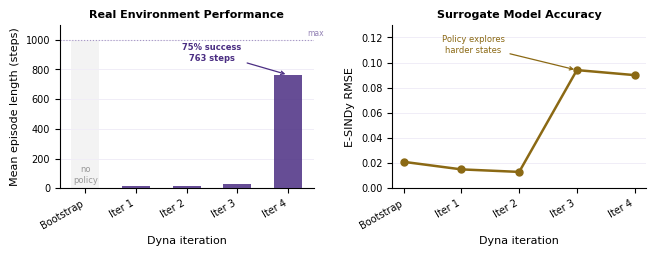

In [3]:
# ── Figure 5 — two side-by-side panels ──────────────────────────────────────
fig, (axL, axR) = plt.subplots(1, 2, figsize=(6.5, 2.5), sharey=False)

bar_width = 0.55
valid     = ~np.isnan(ep_len)

# ═══════════════════════════════════════════════════════════
# LEFT PANEL — mean real episode length
# ═══════════════════════════════════════════════════════════
axL.bar(
    x[valid], ep_len[valid],
    width=bar_width,
    color=UW_PURPLE,
    alpha=0.85,
    zorder=3,
)
axL.bar(x[0], 1000, width=bar_width, color=GREY, alpha=0.22, zorder=1)
axL.text(x[0], 25, "no\npolicy", ha="center", va="bottom",
         fontsize=6, color="#999999")

axL.axhline(1000, color=UW_PURPLE, linewidth=0.8, linestyle=":", alpha=0.45, zorder=2)
axL.text(4.38, 1012, "max", fontsize=5.5, color=UW_PURPLE, alpha=0.6, va="bottom")

axL.annotate(
    f"{CONV_SUCCESS} success\n{CONV_LEN} steps",
    xy=(CONV_ITER, CONV_LEN),
    xytext=(CONV_ITER - 1.5, 860),
    fontsize=6,
    color=UW_PURPLE,
    fontweight="bold",
    ha="center",
    arrowprops=dict(arrowstyle="->", color=UW_PURPLE, lw=0.9),
)

axL.set_title("Real Environment Performance", fontsize=8, fontweight="bold", pad=5)
axL.set_ylabel("Mean episode length (steps)", fontsize=8)
axL.set_ylim(0, 1100)
axL.set_xticks(x)
axL.set_xticklabels(labels, fontsize=7, rotation=30, ha="right")
axL.set_xlabel("Dyna iteration", fontsize=8)
axL.tick_params(axis="y", labelsize=7)
axL.set_facecolor("white")
axL.grid(axis="y", color=UW_LIGHT, linewidth=0.7, zorder=0)
axL.spines["top"].set_visible(False)
axL.spines["right"].set_visible(False)

# ═══════════════════════════════════════════════════════════
# RIGHT PANEL — SINDy RMSE
# ═══════════════════════════════════════════════════════════
axR.plot(
    x, rmse,
    color=UW_GOLD_DK,
    linewidth=1.8,
    marker="o",
    markersize=5,
    zorder=4,
)

axR.annotate(
    "Policy explores\nharder states",
    xy=(3, 0.094),
    xytext=(1.2, 0.108),
    fontsize=6,
    color=UW_GOLD_DK,
    ha="center",
    arrowprops=dict(arrowstyle="->", color=UW_GOLD_DK, lw=0.9),
)

axR.set_title("Surrogate Model Accuracy", fontsize=8, fontweight="bold", pad=5)
axR.set_ylabel("E-SINDy RMSE", fontsize=8)
axR.set_ylim(0, 0.13)
axR.set_xticks(x)
axR.set_xticklabels(labels, fontsize=7, rotation=30, ha="right")
axR.set_xlabel("Dyna iteration", fontsize=8)
axR.tick_params(axis="y", labelsize=7)
axR.set_facecolor("white")
axR.grid(axis="y", color=UW_LIGHT, linewidth=0.7, zorder=0)
axR.spines["top"].set_visible(False)
axR.spines["right"].set_visible(False)

plt.tight_layout(pad=0.5, w_pad=1.5)

for ext in ["pdf", "png"]:
    fp = FIG_DIR / f"fig5_convergence.{ext}"
    fig.savefig(fp, dpi=300, bbox_inches="tight")
    print(f"Saved: {fp}")

plt.show()


In [4]:
# ── Suggested caption ─────────────────────────────────────────────────────────
caption = """
Figure 5. Dyna loop convergence over four iterations.
Bars (left axis, purple): mean episode length in the real MuJoCo environment after deploying
the current best policy. Line (right axis, gold): E-SINDy one-step RMSE on held-out
near-upright transitions. Bootstrap (iteration 0) produces no evaluable policy.
The RMSE rise at iteration 3 reflects the policy exploring states further from upright
as it improves — the surrogate sees a harder distribution, yet the resulting policy
still transfers, achieving 75% task success at iteration 4 using only 27,512
real-environment steps (14.5× fewer than the full-order baseline).
"""
print(caption.strip())

Figure 5. Dyna loop convergence over four iterations.
Bars (left axis, purple): mean episode length in the real MuJoCo environment after deploying
the current best policy. Line (right axis, gold): E-SINDy one-step RMSE on held-out
near-upright transitions. Bootstrap (iteration 0) produces no evaluable policy.
The RMSE rise at iteration 3 reflects the policy exploring states further from upright
as it improves — the surrogate sees a harder distribution, yet the resulting policy
still transfers, achieving 75% task success at iteration 4 using only 27,512
real-environment steps (14.5× fewer than the full-order baseline).


---

## Figure 6 — Method Comparison

Three-method bar chart comparing:
- **(a)** Task success rate (%)
- **(b)** Mean episode length (steps)

across Baseline PPO, SINDy-RL NN, and Sparse Polynomial.

**Data source:** `notebooks/sindy-rl.ipynb` §7 Summary table.

In [5]:
# ── Data from sindy-rl.ipynb §7 Summary ─────────────────────────────────────
# Exact values from notebook output:
#   Baseline PPO:        400,000 real-env steps, mean_len=1000, success=100%
#   SINDy-RL Best NN:     27,512 real-env steps, mean_len=763,  success=75%
#   SINDy-RL Sparse poly: 77,512 real-env steps, mean_len=672,  success=65%
# Note: Sparse poly step count includes 50k distillation rollouts (N_EXPERT=50k)

methods       = ["Baseline\nPPO", "SINDy-RL\nNN", "Sparse\nPolynomial"]
success_pct   = [100,  75,  65]           # success rate (%)
mean_ep_len   = [1000, 763, 672]          # mean episode length (steps)
real_env_steps = [400_000, 27_512, 77_512]  # total real-environment steps

# colours: baseline=grey, NN=purple, sparse=gold
COLORS = ["#999999", UW_PURPLE, UW_GOLD_DK]

print("Method comparison data:")
for m, s, l, n in zip(methods, success_pct, mean_ep_len, real_env_steps):
    label = m.replace("\n", " ")
    print(f"  {label:22s}  success={s}%  ep_len={l}  steps={n:,}")

Method comparison data:
  Baseline PPO            success=100%  ep_len=1000  steps=400,000
  SINDy-RL NN             success=75%  ep_len=763  steps=27,512
  Sparse Polynomial       success=65%  ep_len=672  steps=77,512


Saved: figures/fig6_comparison.pdf
Saved: figures/fig6_comparison.png


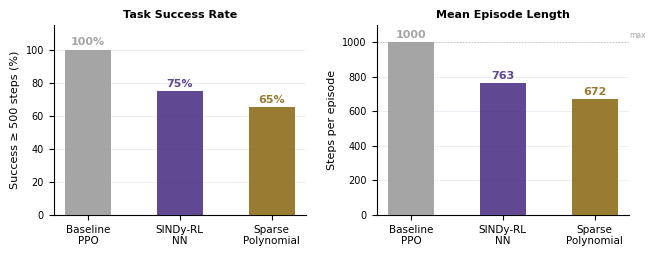

In [6]:
# ── Figure 6 — Method comparison ─────────────────────────────────────────────
fig, (axL, axR) = plt.subplots(1, 2, figsize=(6.5, 2.5))

x = np.arange(len(methods))
bar_w = 0.5

# ═══════════════════════════════════════════════════════════
# LEFT PANEL — task success rate
# ═══════════════════════════════════════════════════════════
bars = axL.bar(x, success_pct, width=bar_w, color=COLORS, alpha=0.88, zorder=3)

# Value labels on top of bars
for bar, val in zip(bars, success_pct):
    axL.text(bar.get_x() + bar.get_width() / 2, val + 1.5,
             f"{val}%", ha="center", va="bottom", fontsize=8, fontweight="bold",
             color=bar.get_facecolor())

axL.set_title("Task Success Rate", fontsize=8, fontweight="bold", pad=5)
axL.set_ylabel("Success ≥ 500 steps (%)", fontsize=8)
axL.set_ylim(0, 115)
axL.set_xticks(x)
axL.set_xticklabels(methods, fontsize=7.5)
axL.tick_params(axis="y", labelsize=7)
axL.set_facecolor("white")
axL.grid(axis="y", color=UW_LIGHT, linewidth=0.7, zorder=0)
axL.spines["top"].set_visible(False)
axL.spines["right"].set_visible(False)

# ═══════════════════════════════════════════════════════════
# RIGHT PANEL — mean episode length
# ═══════════════════════════════════════════════════════════
bars2 = axR.bar(x, mean_ep_len, width=bar_w, color=COLORS, alpha=0.88, zorder=3)

# Value labels
for bar, val in zip(bars2, mean_ep_len):
    axR.text(bar.get_x() + bar.get_width() / 2, val + 10,
             str(val), ha="center", va="bottom", fontsize=8, fontweight="bold",
             color=bar.get_facecolor())

axR.axhline(1000, color="#999999", linewidth=0.8, linestyle=":", alpha=0.5, zorder=2)
axR.text(2.38, 1012, "max", fontsize=5.5, color="#888888", alpha=0.7, va="bottom")

axR.set_title("Mean Episode Length", fontsize=8, fontweight="bold", pad=5)
axR.set_ylabel("Steps per episode", fontsize=8)
axR.set_ylim(0, 1100)
axR.set_xticks(x)
axR.set_xticklabels(methods, fontsize=7.5)
axR.tick_params(axis="y", labelsize=7)
axR.set_facecolor("white")
axR.grid(axis="y", color=UW_LIGHT, linewidth=0.7, zorder=0)
axR.spines["top"].set_visible(False)
axR.spines["right"].set_visible(False)

plt.tight_layout(pad=0.5, w_pad=1.5)

for ext in ["pdf", "png"]:
    fp = FIG_DIR / f"fig6_comparison.{ext}"
    fig.savefig(fp, dpi=300, bbox_inches="tight")
    print(f"Saved: {fp}")

plt.show()

In [7]:
# ── Suggested caption ─────────────────────────────────────────────────────────
caption = """
Figure 6. Method comparison across three policies on the double-pendulum
balancing task. Left: task success rate (fraction of 100 evaluation episodes
reaching ≥ 500 steps). Right: mean episode length.
Baseline PPO (grey) uses 400,000 real-environment steps and achieves 100% success.
The SINDy-RL NN policy (purple) uses only 27,512 steps — a 14.5× reduction —
with 75% success. The sparse polynomial (gold), distilled from the Dyna-loop NN
via degree-3 behavioral cloning (165 terms), achieves 65% success using
77,512 total steps (including 50k distillation rollouts).
"""
print(caption.strip())

Figure 6. Method comparison across three policies on the double-pendulum
balancing task. Left: task success rate (fraction of 100 evaluation episodes
reaching ≥ 500 steps). Right: mean episode length.
Baseline PPO (grey) uses 400,000 real-environment steps and achieves 100% success.
The SINDy-RL NN policy (purple) uses only 27,512 steps — a 14.5× reduction —
with 75% success. The sparse polynomial (gold), distilled from the Dyna-loop NN
via degree-3 behavioral cloning (165 terms), achieves 65% success using
77,512 total steps (including 50k distillation rollouts).
